<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 1

Perform hyperparameter search regarding the C value of the SVM model on the Iris data set. The search space is between 0.0 and 5 (C $\in$ [0.0, 5]) with step size 0.5. Visualize the results of this investigation on a plot. (2p)

[INFO] loading data...
X_train shape: (112, 4)
X_test shape: (38, 4)
Y_train shape: (112,)
Y_test shape: (38,)
[INFO] starting hyperparameter search for SVM C parameter...

[INFO] training SVM with C=0.5
Accuracy of SVM (C=0.5): 0.947

[INFO] training SVM with C=1.0
Accuracy of SVM (C=1.0): 0.974

[INFO] training SVM with C=1.5
Accuracy of SVM (C=1.5): 0.947

[INFO] training SVM with C=2.0
Accuracy of SVM (C=2.0): 0.947

[INFO] training SVM with C=2.5
Accuracy of SVM (C=2.5): 0.947

[INFO] training SVM with C=3.0
Accuracy of SVM (C=3.0): 0.947

[INFO] training SVM with C=3.5
Accuracy of SVM (C=3.5): 0.947

[INFO] training SVM with C=4.0
Accuracy of SVM (C=4.0): 0.947

[INFO] training SVM with C=4.5
Accuracy of SVM (C=4.5): 0.947

[INFO] training SVM with C=5.0
Accuracy of SVM (C=5.0): 0.947

[INFO] visualizing hyperparameter search results...


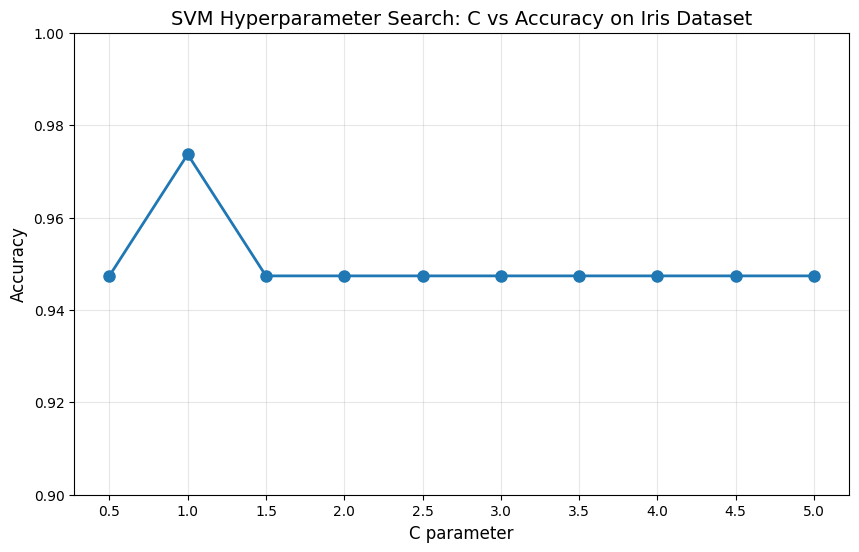


[INFO] Best C value: 1.0 with accuracy: 0.974


In [6]:
# import warnings to suppress convergence warnings
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

print("[INFO] loading data...")
dataset = load_iris()
(trainX, testX, trainY, testY) = train_test_split(dataset.data, dataset.target, random_state=3, test_size=0.25)

print("X_train shape: {}".format(trainX.shape))
print("X_test shape: {}".format(testX.shape))
print("Y_train shape: {}".format(trainY.shape))
print("Y_test shape: {}".format(testY.shape))


# define the search space for C parameter
# C values range from 0.5 to 5.0 with step size 0.5
# Note: C must be > 0.0, so we start from 0.5 instead of 0.0
c_values = np.arange(0.5, 5.5, 0.5)
accuracies = []

print("[INFO] starting hyperparameter search for SVM C parameter...\n")

# loop over all C values
for c in c_values:
	print("[INFO] training SVM with C={:.1f}".format(c))

	# create SVM model
	svm_model = SVC(kernel="rbf", C=c, gamma="auto")
	svm_model.fit(trainX, trainY)

	predictions = svm_model.predict(testX)

	#  accuracy
	accuracy = np.sum(predictions == testY) / len(testY)
	accuracies.append(accuracy)

	print("Accuracy of SVM (C={:.1f}): {:.3f}\n".format(c, accuracy))

# visualize the results
print("[INFO] visualizing hyperparameter search results...")
fig = plt.figure(figsize=(10, 6))
plt.plot(c_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('C parameter', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM Hyperparameter Search: C vs Accuracy on Iris Dataset', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(c_values)
plt.ylim([0.9, 1.0])
plt.show()

# print the best C value and its accuracy
best_idx = np.argmax(accuracies)
best_c = c_values[best_idx]
best_accuracy = accuracies[best_idx]
print("\n[INFO] Best C value: {:.1f} with accuracy: {:.3f}".format(best_c, best_accuracy))